# 路径管理

In [40]:
import sys
import os

# 将 FDCL_v2 项目根目录加入系统路径
project_root = "/root/FDCL_v2"
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 验证路径是否已加入
print("当前 sys.path 包含:")
for p in sys.path[:5]:
    print(f"  {p}")

# 现在可以正常导入 SDK 模块
try:
    from SDK.data.label_mappping import remap_labels, apply_label_mapping
    print("导入成功！")
except ImportError as e:
    print(f"导入失败: {e}")
    print("请检查 SDK 目录结构是否完整。")

当前 sys.path 包含:
  /root/FDCL_v2
  /root/miniconda3/lib/python312.zip
  /root/miniconda3/lib/python3.12
  /root/miniconda3/lib/python3.12/lib-dynload
  
导入成功！


# 数据预处理

In [41]:
import os
import yaml
import numpy as np
import pandas as pd
import torch

# =========================================================
# 配置文件路径
# =========================================================
config_path = "/root/FDCL_v2/CPC/config.yaml"

with open(config_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# 读取 stage2 数据路径（原来为 stage1）
stage2_cfg = cfg["stage2"]
data_paths = stage2_cfg["data_path"]

train_path = data_paths["train_path"]
val_path   = data_paths["val_path"]
test_path  = data_paths["test_path"]

# 检查文件是否存在
for path, name in [(train_path, "train"), (val_path, "val"), (test_path, "test")]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到 stage2 {name} 文件: {path}")

# =========================================================
# 指定要读取的列
# =========================================================
feature_cols = ["vibration_ch1", "vibration_ch2", "vibration_ch3", "vibration_ch4"]
label_col = "class_id"

# =========================================================
# 只读取需要的列
# =========================================================
use_cols = feature_cols + [label_col]

train_df = pd.read_csv(train_path, usecols=use_cols)
val_df   = pd.read_csv(val_path, usecols=use_cols)
test_df  = pd.read_csv(test_path, usecols=use_cols)

print("Stage2 train shape:", train_df.shape)
print("Stage2 val shape  :", val_df.shape)
print("Stage2 test shape :", test_df.shape)

# =========================================================
# 提取特征和标签
# =========================================================
def extract_features_labels(df, feature_cols, label_col):
    X = df[feature_cols].values.astype(np.float32)
    y = df[label_col].values.astype(np.int64).reshape(-1)
    return X, y

X_train, y_train = extract_features_labels(train_df, feature_cols, label_col)
X_val, y_val     = extract_features_labels(val_df, feature_cols, label_col)
X_test, y_test   = extract_features_labels(test_df, feature_cols, label_col)

print("\nRaw feature shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

print("\nLabel statistics:")
print("Train unique classes:", np.unique(y_train))
print("Val   unique classes:", np.unique(y_val))
print("Test  unique classes:", np.unique(y_test))

# =========================================================
# 转换为 PyTorch Tensor
# =========================================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

print("\nFinal tensor shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

Stage2 train shape: (15000, 5)
Stage2 val shape  : (5000, 5)
Stage2 test shape : (5000, 5)

Raw feature shapes:
X_train: (15000, 4) y_train: (15000,)
X_val  : (5000, 4) y_val  : (5000,)
X_test : (5000, 4) y_test : (5000,)

Label statistics:
Train unique classes: [1 4 5 6 7]
Val   unique classes: [1 4 5 6 7]
Test  unique classes: [1 4 5 6 7]

Final tensor shapes:
X_train: torch.Size([15000, 4]) y_train: torch.Size([15000])
X_val  : torch.Size([5000, 4]) y_val  : torch.Size([5000])
X_test : torch.Size([5000, 4]) y_test : torch.Size([5000])


## 原始数据tsne图

已抽样 3000 个样本用于绘图
正在执行 t-SNE，请耐心等待...


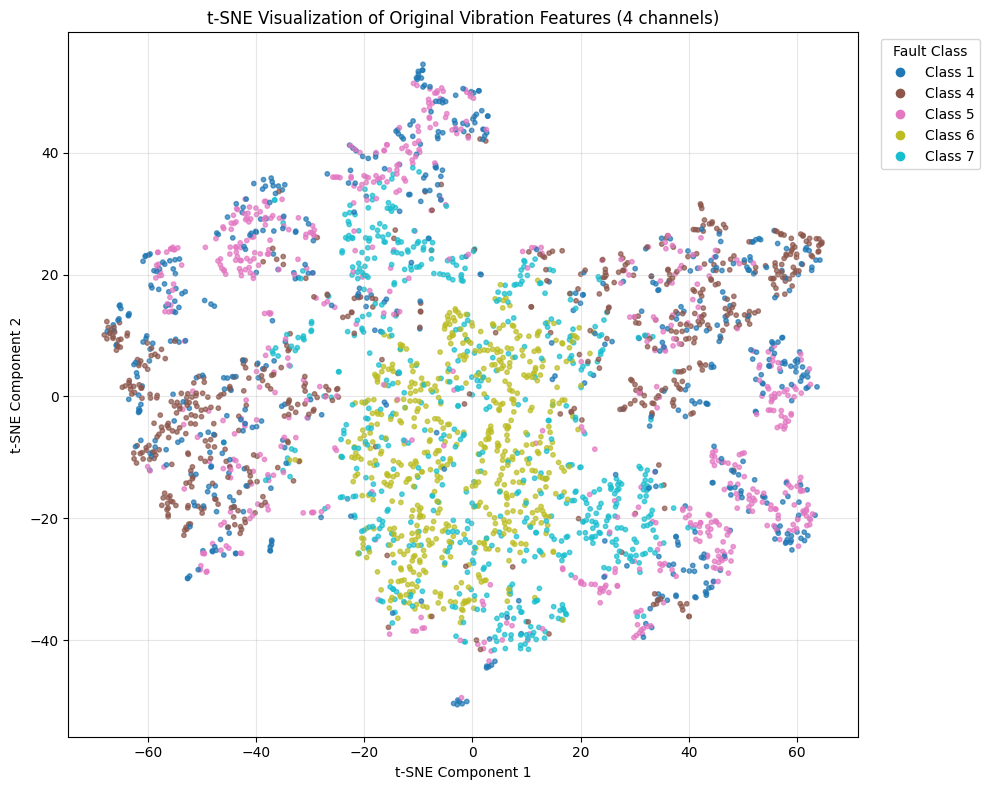

In [42]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# =========================================================
# 数据准备（确保 X_train, y_train 已存在）
# =========================================================
if hasattr(X_train, 'numpy'):
    X_np = X_train.numpy()
    y_np = y_train.numpy()
else:
    X_np = np.array(X_train)
    y_np = np.array(y_train)

# 抽样避免过慢
max_samples = 3000
if X_np.shape[0] > max_samples:
    indices = np.random.choice(X_np.shape[0], max_samples, replace=False)
    X_plot = X_np[indices]
    y_plot = y_np[indices]
    print(f"已抽样 {max_samples} 个样本用于绘图")
else:
    X_plot = X_np
    y_plot = y_np

# =========================================================
# t-SNE 降维（兼容多版本参数）
# =========================================================
print("正在执行 t-SNE，请耐心等待...")

# 尝试使用新版参数 'max_iter'，若失败则回退至旧版 'n_iter'
try:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
except TypeError:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)

X_tsne = tsne.fit_transform(X_plot)

# =========================================================
# 绘图
# =========================================================
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_plot, cmap='tab10', alpha=0.7, s=10)

# 图例
classes = np.unique(y_plot)
legend_handles = []
for cls in classes:
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor=scatter.cmap(scatter.norm(cls)),
                                     markersize=8, label=f'Class {cls}'))
plt.legend(handles=legend_handles, title='Fault Class', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.title('t-SNE Visualization of Original Vibration Features (4 channels)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 滑窗处理，转换成符合CPC输入条件的数据

In [43]:
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# =========================================================
# 可调参数
# =========================================================
WINDOW_SIZE = 256      # 每个样本的时间步长
STRIDE = 128            # 滑动步长（重叠采样可增加数据量）
# RANDOM_SEED = 42

# =========================================================
# 假设你已经执行过前面的数据读取代码，变量如下：
# train_df, val_df, test_df: pandas DataFrame，包含原始时序数据
# feature_cols = ["vibration_ch1", "vibration_ch2", "vibration_ch3", "vibration_ch4"]
# label_col = "class_id"
# =========================================================

# -------------------- 辅助函数：创建序列 --------------------
def create_sequences_from_df(df, feature_cols, label_col, window_size, stride):
    """
    将按时间排序的 DataFrame 转换为滑动窗口序列。
    返回: X_seq (num_windows, channels, window_size), y_seq (num_windows,)
    """
    # 提取数值并保持原始顺序（假定 df 已经按时间排列）
    data = df[feature_cols].values.astype(np.float32)   # (T, C)
    labels = df[label_col].values.astype(np.int64)      # (T,)

    X_list, y_list = [], []
    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        window = data[start:end]                # (window_size, C)
        X_list.append(window.T)                 # 转置为 (C, window_size)
        y_list.append(labels[end - 1])          # 使用窗口末尾的标签

    X_seq = np.stack(X_list, axis=0)            # (N, C, window_size)
    y_seq = np.array(y_list)
    return X_seq, y_seq

# -------------------- 标准化 --------------------
# 使用训练集计算均值和标准差
scaler = StandardScaler()
train_raw = train_df[feature_cols].values.astype(np.float32)
scaler.fit(train_raw)

def scale_df(df):
    data = df[feature_cols].values.astype(np.float32)
    scaled = scaler.transform(data)
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaled
    return df_scaled

train_scaled = scale_df(train_df)
val_scaled   = scale_df(val_df)
test_scaled  = scale_df(test_df)

# -------------------- 生成序列 --------------------
print("正在生成 CPC 序列...")
X_train_cpc, y_train_cpc = create_sequences_from_df(
    train_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
)
X_val_cpc, y_val_cpc = create_sequences_from_df(
    val_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
)
X_test_cpc, y_test_cpc = create_sequences_from_df(
    test_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
)

# -------------------- 转为 Tensor --------------------
X_train_stage2_cpc = torch.tensor(X_train_cpc, dtype=torch.float32)
y_train_stage2_cpc = torch.tensor(y_train_cpc, dtype=torch.long)
X_val_stage2_cpc   = torch.tensor(X_val_cpc, dtype=torch.float32)
y_val_stage2_cpc   = torch.tensor(y_val_cpc, dtype=torch.long)
X_test_stage2_cpc  = torch.tensor(X_test_cpc, dtype=torch.float32)
y_test_stage2_cpc  = torch.tensor(y_test_cpc, dtype=torch.long)

# -------------------- 输出信息 --------------------
print("\n✅ CPC 格式数据生成完成！")
print("=" * 50)
print(f"窗口长度     : {WINDOW_SIZE}")
print(f"滑动步长     : {STRIDE}")
print(f"通道数       : {len(feature_cols)} ({', '.join(feature_cols)})")
print("-" * 50)
print(f"训练集序列数 : {X_train_cpc.shape[0]}")
print(f"验证集序列数 : {X_val_cpc.shape[0]}")
print(f"测试集序列数 : {X_test_cpc.shape[0]}")
print("-" * 50)
print("张量形状 (batch, channels, seq_len):")
print(f"X_train_cpc : {tuple(X_train_cpc.shape)}")
print(f"X_val_cpc   : {tuple(X_val_cpc.shape)}")
print(f"X_test_cpc  : {tuple(X_test_cpc.shape)}")
print("=" * 50)

# 可选：查看一个样本的统计信息
print(f"\n示例 - 第一个训练序列的均值: {X_train_cpc[0].mean():.4f}, 标准差: {X_train_cpc[0].std():.4f}")
print(f"对应标签: {y_train_cpc[0].item()}")

正在生成 CPC 序列...

✅ CPC 格式数据生成完成！
窗口长度     : 256
滑动步长     : 128
通道数       : 4 (vibration_ch1, vibration_ch2, vibration_ch3, vibration_ch4)
--------------------------------------------------
训练集序列数 : 116
验证集序列数 : 38
测试集序列数 : 38
--------------------------------------------------
张量形状 (batch, channels, seq_len):
X_train_cpc : (116, 4, 256)
X_val_cpc   : (38, 4, 256)
X_test_cpc  : (38, 4, 256)

示例 - 第一个训练序列的均值: 0.0087, 标准差: 1.3068
对应标签: 1


## stage1 数据读取和预处理

In [44]:
import os
import yaml
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

# =========================================================
# 配置文件路径
# =========================================================
config_path = "/root/FDCL_v2/CPC/config.yaml"

with open(config_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# 读取 stage1 数据路径（训练集和测试集）
stage1_cfg = cfg["stage1"]
data_paths = stage1_cfg["data_path"]
train_path = data_paths["train_path"]
test_path  = data_paths["test_path"]

# 检查文件是否存在
for path, name in [(train_path, "train"), (test_path, "test")]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"找不到 stage1 {name} 文件: {path}")

# =========================================================
# 指定要读取的列
# =========================================================
feature_cols = ["vibration_ch1", "vibration_ch2", "vibration_ch3", "vibration_ch4"]
label_col = "class_id"

# 只读取需要的列
use_cols = feature_cols + [label_col]
train_df = pd.read_csv(train_path, usecols=use_cols)
test_df  = pd.read_csv(test_path, usecols=use_cols)

print("Stage1 train shape:", train_df.shape)
print("Stage1 test shape :", test_df.shape)

# =========================================================
# 滑动窗口参数（需与 CPC 训练时保持一致）
# =========================================================
WINDOW_SIZE = 256
STRIDE = 128

# =========================================================
# 标准化：使用训练集统计量
# =========================================================
scaler = StandardScaler()
train_raw = train_df[feature_cols].values.astype(np.float32)
scaler.fit(train_raw)

def scale_df(df):
    data = df[feature_cols].values.astype(np.float32)
    scaled = scaler.transform(data)
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaled
    return df_scaled

train_scaled = scale_df(train_df)
test_scaled  = scale_df(test_df)

# =========================================================
# 滑动窗口切分函数
# =========================================================
def create_sequences_from_df(df, feature_cols, label_col, window_size, stride):
    """
    将按时间排序的 DataFrame 转换为滑动窗口序列。
    返回: X_seq (num_windows, channels, window_size), y_seq (num_windows,)
    """
    data = df[feature_cols].values.astype(np.float32)   # (T, C)
    labels = df[label_col].values.astype(np.int64)      # (T,)

    X_list, y_list = [], []
    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        window = data[start:end]                # (window_size, C)
        X_list.append(window.T)                 # 转置为 (C, window_size)
        y_list.append(labels[end - 1])          # 使用窗口末尾的标签

    X_seq = np.stack(X_list, axis=0)            # (N, C, window_size)
    y_seq = np.array(y_list)
    return X_seq, y_seq

# =========================================================
# 生成序列（变量名加入 _stage1 后缀）
# =========================================================
print("\n正在生成 Stage1 CPC 序列...")
X_train_stage1_cpc, y_train_stage1_cpc = create_sequences_from_df(
    train_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
)
X_test_stage1_cpc, y_test_stage1_cpc = create_sequences_from_df(
    test_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
)

# =========================================================
# 转换为 PyTorch Tensor
# =========================================================
X_train_stage1_cpc = torch.tensor(X_train_stage1_cpc, dtype=torch.float32)
y_train_stage1_cpc = torch.tensor(y_train_stage1_cpc, dtype=torch.long)
X_test_stage1_cpc  = torch.tensor(X_test_stage1_cpc, dtype=torch.float32)
y_test_stage1_cpc  = torch.tensor(y_test_stage1_cpc, dtype=torch.long)

# =========================================================
# 输出信息
# =========================================================
print("\n✅ Stage1 CPC 格式数据生成完成！")
print("=" * 50)
print(f"窗口长度 : {WINDOW_SIZE}")
print(f"滑动步长 : {STRIDE}")
print(f"通道数   : {len(feature_cols)}")
print("-" * 50)
print(f"训练集序列数 : {X_train_stage1_cpc.shape[0]}")
print(f"测试集序列数 : {X_test_stage1_cpc.shape[0]}")
print("-" * 50)
print("张量形状 (batch, channels, seq_len):")
print(f"X_train_stage1_cpc : {tuple(X_train_stage1_cpc.shape)}")
print(f"X_test_stage1_cpc  : {tuple(X_test_stage1_cpc.shape)}")
print("=" * 50)

# 标签统计
print(f"\n训练集标签唯一值: {torch.unique(y_train_stage1_cpc).tolist()}")
print(f"测试集标签唯一值: {torch.unique(y_test_stage1_cpc).tolist()}")

Stage1 train shape: (15000, 5)
Stage1 test shape : (5000, 5)

正在生成 Stage1 CPC 序列...

✅ Stage1 CPC 格式数据生成完成！
窗口长度 : 256
滑动步长 : 128
通道数   : 4
--------------------------------------------------
训练集序列数 : 116
测试集序列数 : 38
--------------------------------------------------
张量形状 (batch, channels, seq_len):
X_train_stage1_cpc : (116, 4, 256)
X_test_stage1_cpc  : (38, 4, 256)

训练集标签唯一值: [0, 1, 3, 4, 5]
测试集标签唯一值: [0, 1, 3, 4, 5]


# CPC动态特征计算

## CPC模型定义

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CPCEncoder(nn.Module):
    """编码器：将原始输入映射到潜在表示 z_t"""
    def __init__(self, input_dim, hidden_dim, z_dim):
        super().__init__()
        # 示例：一个简单的卷积编码器（适用于时序数据）
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, z_dim, kernel_size=3, stride=1, padding=1)
        )
    
    def forward(self, x):
        # x 形状: (batch, input_dim, seq_len)
        return self.conv(x)  # 输出: (batch, z_dim, seq_len)

class CPCAutoregressive(nn.Module):
    """自回归模型：根据过去的 z 生成上下文向量 c_t"""
    def __init__(self, z_dim, hidden_dim, context_dim):
        super().__init__()
        self.gru = nn.GRU(z_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=False)
        self.fc = nn.Linear(hidden_dim, context_dim)
    
    def forward(self, z):
        # z 形状: (batch, seq_len, z_dim)
        gru_out, _ = self.gru(z)  # gru_out: (batch, seq_len, hidden_dim)
        context = self.fc(gru_out)  # (batch, seq_len, context_dim)
        return context

class CPCPredictor(nn.Module):
    """预测头：对于每一个未来步 k，将上下文向量映射到预测表示"""
    def __init__(self, context_dim, z_dim, num_steps=5):
        super().__init__()
        self.num_steps = num_steps
        # 为每一个预测步 k 学习一个线性变换矩阵 W_k
        self.Wk = nn.ModuleList([
            nn.Linear(context_dim, z_dim, bias=False) for _ in range(num_steps)
        ])
    
    def forward(self, context, k):
        # context: (batch, seq_len, context_dim)
        # 返回对第 k 步未来的预测表示
        return self.Wk[k-1](context)  # (batch, seq_len, z_dim)

class CPCModel(nn.Module):
    """CPC 整体模型"""
    def __init__(self, input_dim, encoder_hidden_dim=256, z_dim=128,
                 ar_hidden_dim=256, context_dim=128, pred_steps=5):
        super().__init__()
        self.pred_steps = pred_steps
        self.z_dim = z_dim
        
        self.encoder = CPCEncoder(input_dim, encoder_hidden_dim, z_dim)
        self.ar = CPCAutoregressive(z_dim, ar_hidden_dim, context_dim)
        self.predictor = CPCPredictor(context_dim, z_dim, pred_steps)
    
    def forward(self, x):
        # x: (batch, input_dim, seq_len)
        batch_size, _, seq_len = x.shape
        
        # 1. 编码得到 z
        z = self.encoder(x)                     # (batch, z_dim, seq_len)
        z = z.permute(0, 2, 1)                  # (batch, seq_len, z_dim)
        
        # 2. 生成上下文向量 c_t
        context = self.ar(z)                    # (batch, seq_len, context_dim)
        
        # 3. 收集正负样本并计算 InfoNCE 损失
        loss, accuracy = self._compute_infonce(z, context)
        return loss, accuracy
    
    def _compute_infonce(self, z, context):
        """
        计算 InfoNCE 损失。
        对每个时间步 t 和每个预测步 k，真实未来 z_{t+k} 为正样本，
        同一批次内其他时间步（或随机采样）的 z 为负样本。
        """
        batch_size, seq_len, z_dim = z.shape
        total_loss = 0.0
        correct = 0
        total = 0
        
        # 循环每个预测步 k
        for k in range(1, self.pred_steps + 1):
            # 预测对第 k 步未来的表示: W_k c_t
            pred = self.predictor(context, k)           # (batch, seq_len, z_dim)
            
            # 正样本：真实的未来 z_{t+k}
            # 为了对齐时间维度，截取有效部分
            t_max = seq_len - k
            if t_max <= 0:
                continue
            
            # 取对应时间的预测和真实未来
            pred_valid = pred[:, :t_max, :]              # (batch, t_max, z_dim)
            z_future = z[:, k:, :]                       # (batch, t_max, z_dim)
            
            # 计算相似度分数（点积）
            # pred_valid: (batch, t_max, z_dim) -> 展平为 (batch * t_max, z_dim)
            # z_all: (batch * seq_len, z_dim) 作为所有候选负样本
            z_all_flat = z.reshape(-1, z_dim)            # (batch * seq_len, z_dim)
            
            # 预测与所有候选的相似度矩阵
            pred_flat = pred_valid.reshape(-1, z_dim)    # (batch * t_max, z_dim)
            logits = torch.matmul(pred_flat, z_all_flat.T)  # (batch * t_max, batch * seq_len)
            
            # 构造标签：正样本的位置索引
            # 对于每个 (batch_i, t)，正样本是同一序列同一批次的未来时间步
            indices = torch.arange(batch_size * t_max, device=z.device)
            labels = (indices // t_max) * seq_len + (indices % t_max) + k
            labels = labels.long()
            
            # 交叉熵损失
            loss_k = F.cross_entropy(logits, labels)
            total_loss += loss_k
            
            # 计算准确率
            pred_idx = logits.argmax(dim=1)
            correct += (pred_idx == labels).sum().item()
            total += labels.size(0)
        
        avg_loss = total_loss / self.pred_steps
        accuracy = correct / total if total > 0 else 0.0
        return avg_loss, accuracy

    def get_representations(self, x):
        """提取特征表示（上下文向量或潜在向量），供下游任务使用"""
        z = self.encoder(x).permute(0, 2, 1)  # (batch, seq_len, z_dim)
        context = self.ar(z)                  # (batch, seq_len, context_dim)
        return context   # 也可选择返回 z


##  旧CPC直接在新数据集上进行测试

CPC 模型加载成功。
使用已存在的 Stage2 序列数据，形状: torch.Size([116, 4, 256])
正在计算 Stage2 训练集每个样本的损失...
Stage2 训练集类别跳变次数: 4


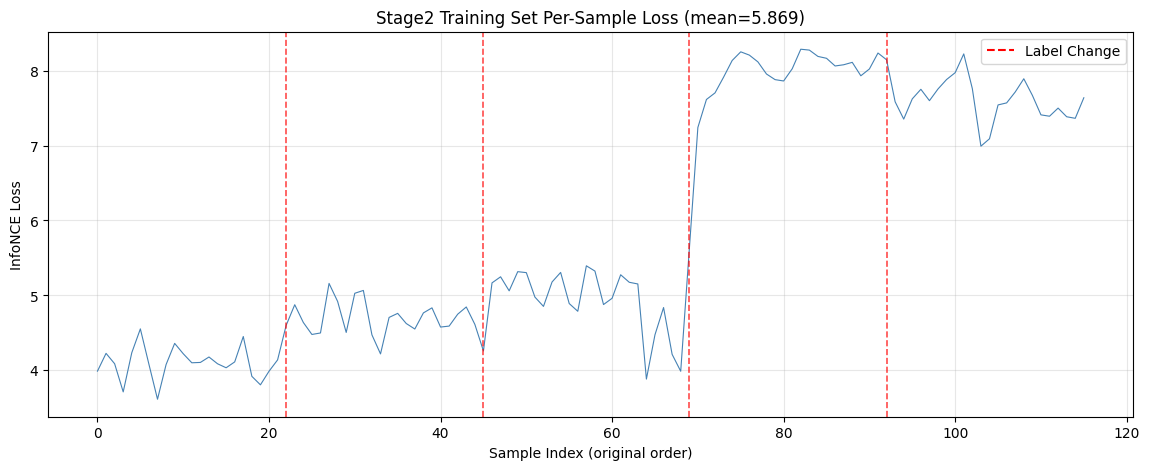

图片已保存至: /root/FDCL_v2/CPC/stage2/result/stage2_train_loss_with_changes.png

===== Stage2 训练集损失统计 =====
样本数: 116
均值: 5.8687
标准差: 1.6262
最小值: 3.6148
最大值: 8.2856

正在提取 CPC 嵌入表达并进行 t-SNE 可视化...
提取的嵌入形状: (116, 128)
正在执行 t-SNE 降维，请耐心等待...


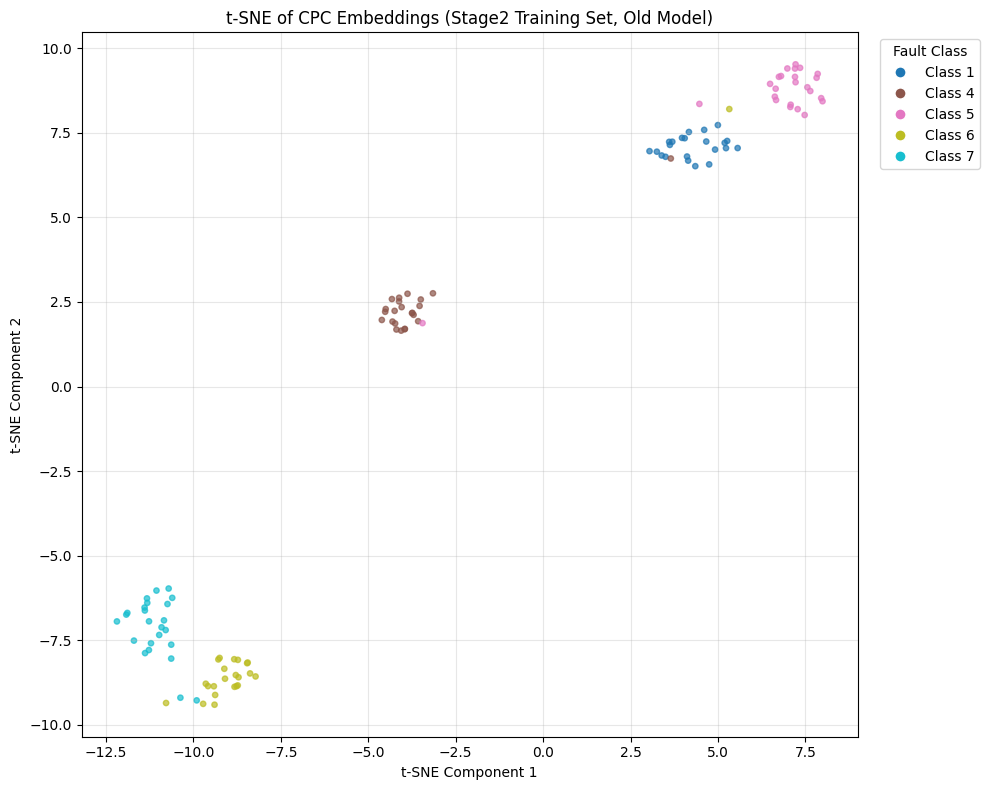

t-SNE 可视化图片已保存至: /root/FDCL_v2/CPC/stage2/result/stage2_cpc_embeddings_tsne.png


In [49]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import os

# =========================================================
# 配置路径与参数
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CPC 模型路径（来自 Stage1 训练结果）
cpc_model_path = "/root/FDCL_v2/CPC/stage1/result/best_cpc_model.pth"

# Stage2 结果保存目录
result_dir = "/root/FDCL_v2/CPC/stage2/result"
os.makedirs(result_dir, exist_ok=True)

# CPC 序列参数（与训练时完全一致）
WINDOW_SIZE = 256
STRIDE = 128
batch_size = 64   # 损失计算时的批次大小

# =========================================================
# 1. 加载 CPC 模型
# =========================================================
# 请确保 CPCModel 类已在当前环境定义（若未定义，请先运行 CPC 类定义 Cell）
model = CPCModel(
    input_dim=4,
    encoder_hidden_dim=256,
    z_dim=128,
    ar_hidden_dim=256,
    context_dim=128,
    pred_steps=5
).to(device)

checkpoint = torch.load(cpc_model_path, map_location=device)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model.eval()
print("CPC 模型加载成功。")

# =========================================================
# 2. 准备 Stage2 训练数据（若未生成序列，则自动处理）
# =========================================================
# 检查是否已有 Stage2 序列数据变量
if 'X_train_stage2_cpc' not in dir():
    print("未找到 Stage2 序列数据，正在从原始 DataFrame 生成...")
    # 请确保 train_df（Stage2训练集原始DataFrame）已存在（运行Stage2数据读取Cell后可得）
    if 'train_df' not in dir():
        raise NameError("变量 train_df 未定义，请先运行 Stage2 数据读取 Cell。")
    
    feature_cols = ["vibration_ch1", "vibration_ch2", "vibration_ch3", "vibration_ch4"]
    label_col = "class_id"
    
    # 标准化
    scaler = StandardScaler()
    train_raw = train_df[feature_cols].values.astype(np.float32)
    scaler.fit(train_raw)
    
    def scale_df(df):
        data = df[feature_cols].values.astype(np.float32)
        scaled = scaler.transform(data)
        df_scaled = df.copy()
        df_scaled[feature_cols] = scaled
        return df_scaled
    
    train_scaled = scale_df(train_df)
    
    # 滑动窗口生成序列
    def create_sequences_from_df(df, feature_cols, label_col, window_size, stride):
        data = df[feature_cols].values.astype(np.float32)
        labels = df[label_col].values.astype(np.int64)
        X_list, y_list = [], []
        for start in range(0, len(data) - window_size + 1, stride):
            end = start + window_size
            window = data[start:end]
            X_list.append(window.T)
            y_list.append(labels[end - 1])
        return np.stack(X_list, axis=0), np.array(y_list)
    
    X_train_stage2_cpc, y_train_stage2_raw = create_sequences_from_df(
        train_scaled, feature_cols, label_col, WINDOW_SIZE, STRIDE
    )
    X_train_stage2_cpc = torch.tensor(X_train_stage2_cpc, dtype=torch.float32)
    y_train_stage2_raw = torch.tensor(y_train_stage2_raw, dtype=torch.long)
    print(f"Stage2 训练序列生成完成，形状: {X_train_stage2_cpc.shape}")
else:
    print(f"使用已存在的 Stage2 序列数据，形状: {X_train_stage2_cpc.shape}")
    # 确保标签也存在
    if 'y_train_stage2_raw' not in dir():
        raise NameError("变量 y_train_stage2_raw 未定义，请确保已生成序列标签。")

# =========================================================
# 3. 定义按样本计算损失的函数
# =========================================================
@torch.no_grad()
def compute_per_sample_loss(model, x):
    """返回形状为 (batch,) 的每个样本平均 InfoNCE 损失"""
    batch_size, _, seq_len = x.shape
    pred_steps = model.pred_steps

    z = model.encoder(x).permute(0, 2, 1)          # (B, T, z_dim)
    context = model.ar(z)                          # (B, T, context_dim)

    per_sample_loss = torch.zeros(batch_size, device=x.device)
    total_counts = torch.zeros(batch_size, device=x.device)

    for k in range(1, pred_steps + 1):
        t_max = seq_len - k
        if t_max <= 0:
            continue
        pred = model.predictor(context, k)[:, :t_max, :]
        z_all_flat = z.reshape(-1, z.shape[-1])

        for b in range(batch_size):
            pred_b = pred[b]
            logits = torch.matmul(pred_b, z_all_flat.T)
            labels = (b * seq_len) + torch.arange(k, k + t_max, device=x.device)
            loss_per_t = F.cross_entropy(logits, labels, reduction='none')
            per_sample_loss[b] += loss_per_t.sum()
            total_counts[b] += t_max

    per_sample_loss = per_sample_loss / total_counts.clamp(min=1)
    return per_sample_loss

# =========================================================
# 4. 分批计算 Stage2 训练集损失
# =========================================================
print("正在计算 Stage2 训练集每个样本的损失...")
losses_stage2 = []
total_samples = X_train_stage2_cpc.shape[0]
for i in range(0, total_samples, batch_size):
    batch_x = X_train_stage2_cpc[i:i+batch_size].to(device)
    loss_batch = compute_per_sample_loss(model, batch_x).cpu().numpy()
    losses_stage2.extend(loss_batch.tolist())
losses_stage2 = np.array(losses_stage2)

# 获取标签（numpy 格式）
y_np = y_train_stage2_raw.numpy() if torch.is_tensor(y_train_stage2_raw) else np.array(y_train_stage2_raw)

# =========================================================
# 5. 找出类别跳变位置
# =========================================================
def find_label_change_indices(labels):
    """返回所有发生标签跳变的样本索引（跳变后的第一个样本位置）"""
    change_indices = np.where(np.diff(labels) != 0)[0] + 1
    return change_indices

stage2_changes = find_label_change_indices(y_np)
print(f"Stage2 训练集类别跳变次数: {len(stage2_changes)}")

# =========================================================
# 6. 绘制折线图（与之前风格一致）
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(range(len(losses_stage2)), losses_stage2, linewidth=0.8, color='steelblue')
for idx in stage2_changes:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

plt.xlabel('Sample Index (original order)')
plt.ylabel('InfoNCE Loss')
plt.title(f'Stage2 Training Set Per-Sample Loss (mean={losses_stage2.mean():.3f})')
plt.grid(alpha=0.3)
plt.plot([], [], color='red', linestyle='--', label='Label Change')
plt.legend()

# 保存图片到新目录
save_path = os.path.join(result_dir, "stage2_train_loss_with_changes.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"图片已保存至: {save_path}")

# =========================================================
# 7. 统计摘要
# =========================================================
print("\n===== Stage2 训练集损失统计 =====")
print(f"样本数: {len(losses_stage2)}")
print(f"均值: {losses_stage2.mean():.4f}")
print(f"标准差: {losses_stage2.std():.4f}")
print(f"最小值: {losses_stage2.min():.4f}")
print(f"最大值: {losses_stage2.max():.4f}")

# =========================================================
# ========== 新增：CPC 嵌入表达 t-SNE 可视化 ==============
# =========================================================
print("\n正在提取 CPC 嵌入表达并进行 t-SNE 可视化...")

# 提取 CPC 特征（全局平均池化上下文向量）
@torch.no_grad()
def extract_cpc_features(model, X_data, batch_size=64):
    features_list = []
    total = X_data.shape[0]
    for i in range(0, total, batch_size):
        batch_x = X_data[i:i+batch_size].to(device)
        context = model.get_representations(batch_x)      # (B, seq_len, context_dim)
        pooled = context.mean(dim=1).cpu().numpy()        # (B, context_dim)
        features_list.append(pooled)
    return np.concatenate(features_list, axis=0)

# 抽样控制（避免 t-SNE 过慢）
max_samples = 2000
X_plot = X_train_stage2_cpu = X_train_stage2_cpc.cpu().numpy() if torch.is_tensor(X_train_stage2_cpc) else X_train_stage2_cpc
y_plot = y_np
if X_plot.shape[0] > max_samples:
    indices = np.random.choice(X_plot.shape[0], max_samples, replace=False)
    X_plot = X_plot[indices]
    y_plot = y_plot[indices]
    print(f"已随机抽样 {max_samples} 个样本用于 t-SNE")
else:
    X_plot = X_plot
    y_plot = y_plot

# 转换为 Tensor 以便送入模型
X_plot_tensor = torch.tensor(X_plot, dtype=torch.float32)
features = extract_cpc_features(model, X_plot_tensor, batch_size=64)
print(f"提取的嵌入形状: {features.shape}")

# t-SNE 降维
print("正在执行 t-SNE 降维，请耐心等待...")
try:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
except TypeError:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)

features_2d = tsne.fit_transform(features)

# 绘制散点图
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=y_plot, cmap='tab10', alpha=0.7, s=15)

# 添加图例
classes = np.unique(y_plot)
legend_handles = []
for cls in classes:
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor=scatter.cmap(scatter.norm(cls)),
                                     markersize=8, label=f'Class {cls}'))
plt.legend(handles=legend_handles, title='Fault Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('t-SNE of CPC Embeddings (Stage2 Training Set, Old Model)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()

# 保存 t-SNE 图
tsne_save_path = os.path.join(result_dir, "stage2_cpc_embeddings_tsne.png")
plt.savefig(tsne_save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"t-SNE 可视化图片已保存至: {tsne_save_path}")

## CPC模型训练

使用设备: cuda
Stage2 总样本数: 116
其中新类别样本数: 47，旧类别样本数: 69
选取 Stage2 新类别样本索引: [69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93]，共 25 个。
Stage1 预训练 CPC 模型加载成功。
从 Stage1 随机选取回放样本: 25 个。

开始增量训练（仅新类别 + 回放）...


Epoch 1/50:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1/50: 100%|██████████| 7/7 [00:00<00:00, 25.55it/s, loss=1.5172, acc=0.5763]


Epoch 1 | Avg Loss: 3.9301 | Avg Acc: 0.2601


Epoch 2/50: 100%|██████████| 7/7 [00:00<00:00, 23.93it/s, loss=3.7727, acc=0.2107]


...

Epoch 48 | Avg Loss: 1.7877 | Avg Acc: 0.6040


Epoch 49/50: 100%|██████████| 7/7 [00:00<00:00, 21.59it/s, loss=0.8714, acc=0.7735]


Epoch 49 | Avg Loss: 1.6441 | Avg Acc: 0.6340


Epoch 50/50: 100%|██████████| 7/7 [00:00<00:00, 21.53it/s, loss=0.9176, acc=0.7640]


Epoch 50 | Avg Loss: 1.6721 | Avg Acc: 0.6135
更新后的模型已保存至: /root/FDCL_v2/CPC/stage2/result/cpc_model_updated_stage2_new_only.pth


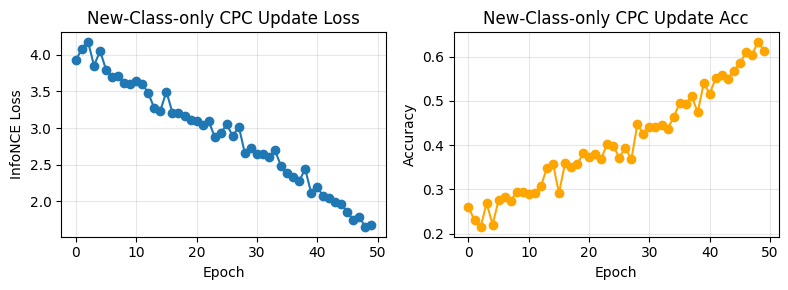


正在计算全部 Stage2 样本的逐样本损失...


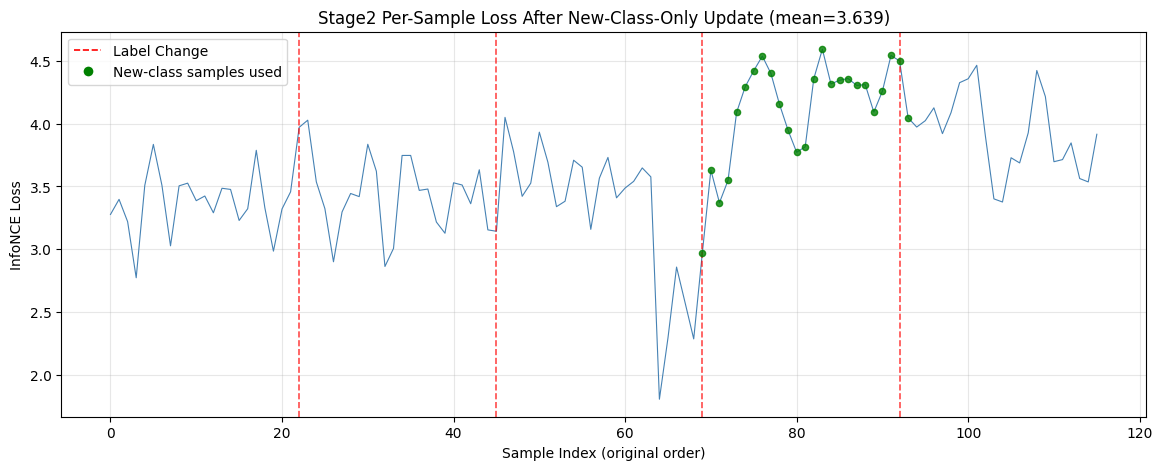

逐样本损失图已保存至: /root/FDCL_v2/CPC/stage2/result/stage2_loss_new_class_only_update.png

增量训练（仅新类别+回放）完成。


In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import pandas as pd

# =========================================================
# 配置参数
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 路径
stage1_model_path = "/root/FDCL_v2/CPC/stage1/result/best_cpc_model.pth"
stage2_result_dir = "/root/FDCL_v2/CPC/stage2/result"
os.makedirs(stage2_result_dir, exist_ok=True)

# 增量训练超参数
batch_size = 8
learning_rate = 1e-4
weight_decay = 1e-5
total_epochs = 50
num_stage2_new_samples_to_use = 25  # 使用 Stage2 中新类别的样本数量
replay_ratio = 1.0                   # 回放样本比例

# =========================================================
# 0. 检查四个必需变量
# =========================================================
required_vars = [
    'X_train_stage1_cpc', 'y_train_stage1_cpc',
    'X_train_stage2_cpc', 'y_train_stage2_cpc'
]
missing = [v for v in required_vars if v not in dir()]
if missing:
    raise NameError(f"缺少变量: {missing}，请先运行数据准备 Cell。")

# =========================================================
# 1. 区分 Stage2 中的新/旧类别样本
# =========================================================
y_stage2 = y_train_stage2_cpc.numpy() if torch.is_tensor(y_train_stage2_cpc) else np.asarray(y_train_stage2_cpc)
stage1_map_df = pd.read_csv("/root/FDCL_v2/CPC/stage1/result/label_mapping.csv")
known_old_labels = set(stage1_map_df["old_label"].astype(int).tolist())

# 判断每个样本是否为新类别（不在已知旧标签集合中）
is_new = np.isin(y_stage2, list(known_old_labels), invert=True)
new_indices = np.where(is_new)[0]
old_indices = np.where(~is_new)[0]

print(f"Stage2 总样本数: {len(y_stage2)}")
print(f"其中新类别样本数: {len(new_indices)}，旧类别样本数: {len(old_indices)}")

if len(new_indices) == 0:
    raise ValueError("Stage2 中没有检测到新类别样本，无法进行基于新类别的增量训练。")

# 选取前 num_stage2_new_samples_to_use 个新类别样本
num_new = min(num_stage2_new_samples_to_use, len(new_indices))
selected_new_indices = new_indices[:num_new]
X_stage2_selected = X_train_stage2_cpc[selected_new_indices]
print(f"选取 Stage2 新类别样本索引: {selected_new_indices.tolist()}，共 {len(X_stage2_selected)} 个。")

# =========================================================
# 2. 加载预训练 CPC 模型
# =========================================================
model = CPCModel(
    input_dim=4,
    encoder_hidden_dim=256,
    z_dim=128,
    ar_hidden_dim=256,
    context_dim=128,
    pred_steps=5
).to(device)

checkpoint = torch.load(stage1_model_path, map_location=device)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
print("Stage1 预训练 CPC 模型加载成功。")

# =========================================================
# 3. 准备训练数据：Stage2 新样本 + Stage1 回放样本
# =========================================================
# 3.1 Stage1 回放采样
num_replay = int(len(X_stage2_selected) * replay_ratio)
indices_replay = np.random.choice(len(X_train_stage1_cpc), size=num_replay, replace=False)
X_replay = X_train_stage1_cpc[indices_replay]
print(f"从 Stage1 随机选取回放样本: {num_replay} 个。")

# 3.2 合并数据集
X_combined = torch.cat([X_stage2_selected, X_replay], dim=0)
y_combined = torch.zeros(len(X_combined), dtype=torch.long)  # 占位标签

combined_dataset = TensorDataset(X_combined, y_combined)
combined_loader = DataLoader(combined_dataset, batch_size=batch_size, shuffle=True)

# =========================================================
# 4. 增量训练循环
# =========================================================
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
model.train()

loss_history = []
acc_history = []

print("\n开始增量训练（仅新类别 + 回放）...")
for epoch in range(total_epochs):
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0

    pbar = tqdm(combined_loader, desc=f"Epoch {epoch+1}/{total_epochs}")
    for batch_x, _ in pbar:
        batch_x = batch_x.to(device)

        optimizer.zero_grad()
        loss, acc = model(batch_x)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += acc
        num_batches += 1

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{acc:.4f}'})

    avg_loss = total_loss / num_batches
    avg_acc = total_acc / num_batches
    loss_history.append(avg_loss)
    acc_history.append(avg_acc)
    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f} | Avg Acc: {avg_acc:.4f}")

# =========================================================
# 5. 保存更新后的模型
# =========================================================
updated_model_path = os.path.join(stage2_result_dir, "cpc_model_updated_stage2_new_only.pth")
torch.save({
    'model_state_dict': model.state_dict(),
    'selected_new_indices': selected_new_indices,
    'num_replay': num_replay,
}, updated_model_path)
print(f"更新后的模型已保存至: {updated_model_path}")

# =========================================================
# 6. 绘制训练曲线
# =========================================================
if total_epochs > 1:
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.plot(loss_history, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('InfoNCE Loss')
    plt.title('New-Class-only CPC Update Loss')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(acc_history, marker='o', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('New-Class-only CPC Update Acc')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(stage2_result_dir, "cpc_new_only_training_curve.png"), dpi=150)
    plt.show()

# =========================================================
# 7. 逐样本损失计算与可视化（全部 Stage2 数据）
# =========================================================
@torch.no_grad()
def compute_per_sample_loss(model, x):
    batch_size, _, seq_len = x.shape
    pred_steps = model.pred_steps
    z = model.encoder(x).permute(0, 2, 1)
    context = model.ar(z)

    per_sample_loss = torch.zeros(batch_size, device=x.device)
    total_counts = torch.zeros(batch_size, device=x.device)

    for k in range(1, pred_steps + 1):
        t_max = seq_len - k
        if t_max <= 0:
            continue
        pred = model.predictor(context, k)[:, :t_max, :]
        z_all_flat = z.reshape(-1, z.shape[-1])

        for b in range(batch_size):
            pred_b = pred[b]
            logits = torch.matmul(pred_b, z_all_flat.T)
            labels = (b * seq_len) + torch.arange(k, k + t_max, device=x.device)
            loss_per_t = torch.nn.functional.cross_entropy(logits, labels, reduction='none')
            per_sample_loss[b] += loss_per_t.sum()
            total_counts[b] += t_max

    per_sample_loss = per_sample_loss / total_counts.clamp(min=1)
    return per_sample_loss

print("\n正在计算全部 Stage2 样本的逐样本损失...")
model.eval()
eval_batch_size = 64
losses_all = []
total_samples = X_train_stage2_cpc.shape[0]
for i in range(0, total_samples, eval_batch_size):
    batch_x = X_train_stage2_cpc[i:i+eval_batch_size].to(device)
    loss_batch = compute_per_sample_loss(model, batch_x).cpu().numpy()
    losses_all.extend(loss_batch.tolist())
losses_all = np.array(losses_all)

# 标签跳变检测
y_plot_raw = y_train_stage2_cpc.numpy() if torch.is_tensor(y_train_stage2_cpc) else np.asarray(y_train_stage2_cpc)
change_indices = np.where(np.diff(y_plot_raw) != 0)[0] + 1

# 绘制损失曲线，并标注训练所用新样本的位置（用绿色散点或竖线标注）
plt.figure(figsize=(14, 5))
plt.plot(range(len(losses_all)), losses_all, linewidth=0.8, color='steelblue')

# 红色虚线：标签跳变
for idx in change_indices:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

# 标注用于训练的新类别样本位置（用绿色点标记在曲线下方）
plt.scatter(selected_new_indices, losses_all[selected_new_indices], 
            color='green', s=20, alpha=0.8, label='New-class samples used', zorder=5)

plt.xlabel('Sample Index (original order)')
plt.ylabel('InfoNCE Loss')
plt.title(f'Stage2 Per-Sample Loss After New-Class-Only Update (mean={losses_all.mean():.3f})')
plt.grid(alpha=0.3)

from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.2),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8)]
plt.legend(custom_lines, ['Label Change', 'New-class samples used'])

loss_plot_path = os.path.join(stage2_result_dir, "stage2_loss_new_class_only_update.png")
plt.savefig(loss_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"逐样本损失图已保存至: {loss_plot_path}")
print("\n增量训练（仅新类别+回放）完成。")

## 训练后的嵌入表达可视化

使用设备: cuda
更新后的 CPC 模型加载成功。
正在提取 CPC 嵌入特征...
提取的嵌入形状: (116, 128)
正在执行 t-SNE 降维，请耐心等待...


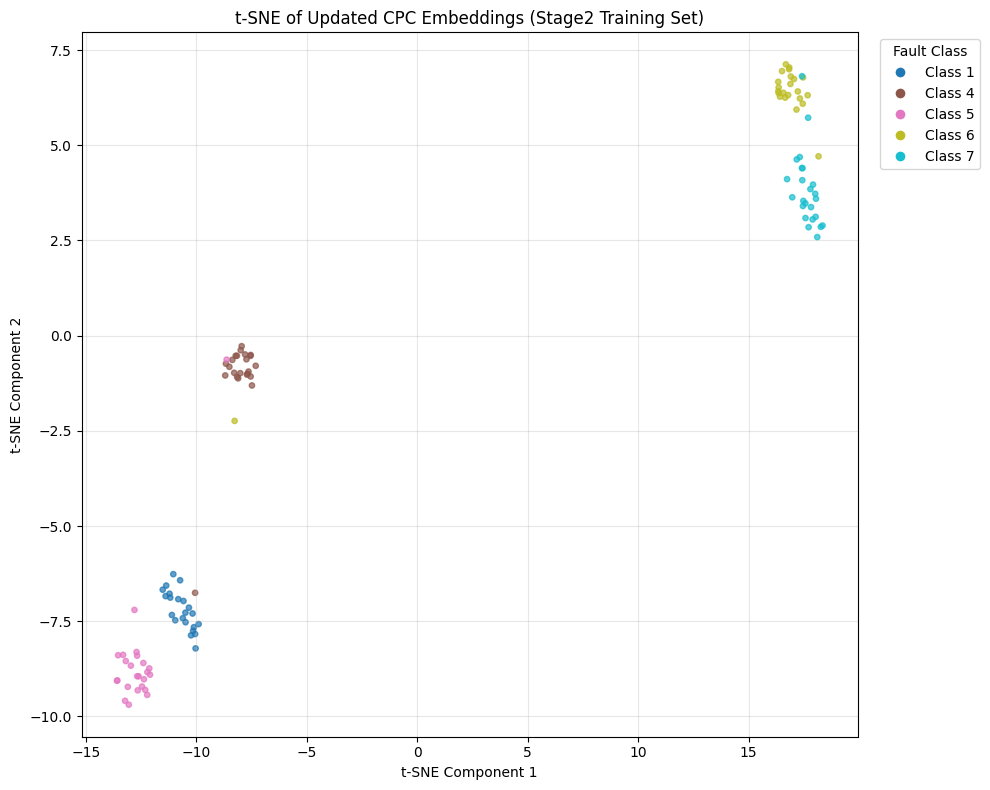

t-SNE 可视化图片已保存至: /root/FDCL_v2/CPC/stage2/result/stage2_updated_cpc_embeddings_tsne.png


In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

# =========================================================
# 配置参数
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 更新后的模型路径（与上一步保存路径一致）
updated_model_path = "/root/FDCL_v2/CPC/stage2/result/cpc_model_updated_stage2_new_only.pth"
result_dir = "/root/FDCL_v2/CPC/stage2/result"
os.makedirs(result_dir, exist_ok=True)

# 可视化参数
max_samples = 2000          # t-SNE 最大样本数（避免过慢）
batch_size_extract = 64     # 特征提取批次大小

# =========================================================
# 1. 加载更新后的 CPC 模型（修复 weights_only 问题）
# =========================================================
# 请确保 CPCModel 类已在当前环境定义
model_updated = CPCModel(
    input_dim=4,
    encoder_hidden_dim=256,
    z_dim=128,
    ar_hidden_dim=256,
    context_dim=128,
    pred_steps=5
).to(device)

# 关键修复：设置 weights_only=False
checkpoint = torch.load(updated_model_path, map_location=device, weights_only=False)
model_updated.load_state_dict(checkpoint['model_state_dict'])
model_updated.eval()
print("更新后的 CPC 模型加载成功。")

# =========================================================
# 2. 提取 CPC 嵌入表达（全局平均池化上下文向量）
# =========================================================
@torch.no_grad()
def extract_cpc_features(model, X_data, batch_size):
    features_list = []
    total = X_data.shape[0]
    for i in range(0, total, batch_size):
        batch_x = X_data[i:i+batch_size].to(device)
        context = model.get_representations(batch_x)      # (B, seq_len, context_dim)
        pooled = context.mean(dim=1).cpu().numpy()        # 时间维平均池化 -> (B, context_dim)
        features_list.append(pooled)
    return np.concatenate(features_list, axis=0)

# 准备数据（使用 Stage2 训练集）
X_data = X_train_stage2_cpc
y_data = y_train_stage2_cpc.numpy() if torch.is_tensor(y_train_stage2_cpc) else np.asarray(y_train_stage2_cpc)

# 若样本过多，随机抽样
if X_data.shape[0] > max_samples:
    indices = np.random.choice(X_data.shape[0], max_samples, replace=False)
    X_plot = X_data[indices]
    y_plot = y_data[indices]
    print(f"已随机抽样 {max_samples} 个样本用于 t-SNE")
else:
    X_plot = X_data
    y_plot = y_data

print("正在提取 CPC 嵌入特征...")
features = extract_cpc_features(model_updated, X_plot, batch_size_extract)
print(f"提取的嵌入形状: {features.shape}")

# =========================================================
# 3. t-SNE 降维
# =========================================================
print("正在执行 t-SNE 降维，请耐心等待...")
try:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
except TypeError:
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)

features_2d = tsne.fit_transform(features)

# =========================================================
# 4. 绘制 t-SNE 散点图
# =========================================================
plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=y_plot, cmap='tab10', alpha=0.7, s=15)

# 添加图例
classes = np.unique(y_plot)
legend_handles = []
for cls in classes:
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor=scatter.cmap(scatter.norm(cls)),
                                     markersize=8, label=f'Class {cls}'))
plt.legend(handles=legend_handles, title='Fault Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('t-SNE of Updated CPC Embeddings (Stage2 Training Set)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()

# 保存图片
tsne_save_path = os.path.join(result_dir, "stage2_updated_cpc_embeddings_tsne.png")
plt.savefig(tsne_save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"t-SNE 可视化图片已保存至: {tsne_save_path}")

# 分类头

## 分类头定义

In [ ]:
import torch
import torch.nn as nn

class MLPClassifier(nn.Module):
    """
    多层感知机分类器
    Args:
        input_dim: 输入特征维度（例如 CPC context_dim 或全局池化后的维度）
        hidden_dims: 列表，每个元素为对应隐藏层的神经元数量，例如 [256, 128]
        num_classes: 分类类别数
        dropout: Dropout 概率，默认 0.3
        use_batch_norm: 是否在隐藏层后使用批归一化，默认 True
        activation: 激活函数，默认 nn.ReLU()
    """
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.3, 
                 use_batch_norm=True, activation=nn.ReLU()):
        super().__init__()
        
        layers = []
        dims = [input_dim] + hidden_dims
        
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(activation)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        
        # 输出层（无激活、无批归一化）
        layers.append(nn.Linear(dims[-1], num_classes))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        x: (batch_size, input_dim)
        返回: logits (batch_size, num_classes)
        """
        return self.net(x)

## MLP初始化

In [ ]:
# =========================================================
# 2. 初始化 MLP（根据你的 CPC 配置和数据集）
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 参数配置（需与你训练 CPC 时的输出维度及数据集类别数一致）
CPC_CONTEXT_DIM = 128        # CPC 上下文向量的维度（你训练时使用的 context_dim）
HIDDEN_DIMS = [256, 128]     # MLP 隐藏层结构
NUM_CLASSES = 5              # 你的故障类别总数（请根据实际数据修改）

mlp_classifier = MLPClassifier(
    input_dim=CPC_CONTEXT_DIM,
    hidden_dims=HIDDEN_DIMS,
    num_classes=NUM_CLASSES,
    dropout=0.3,
    use_batch_norm=True
).to(device)

print(f"MLP 分类器已初始化，结构如下：\n{mlp_classifier}")
print(f"设备: {device}")

# =========================================================
# 3. 可选：查看参数总量
# =========================================================
total_params = sum(p.numel() for p in mlp_classifier.parameters())
trainable_params = sum(p.numel() for p in mlp_classifier.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}，可训练参数量: {trainable_params:,}")

MLP 分类器已初始化，结构如下：
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=5, bias=True)
  )
)
设备: cuda
总参数量: 67,333，可训练参数量: 67,333


## 训练

使用设备: cuda
训练集标签唯一值: tensor([0, 1, 2, 3, 4])
类别数: 5
CPC 模型加载成功。
正在提取训练集 CPC 特征...
正在提取测试集 CPC 特征...
训练特征形状: torch.Size([116, 128])
测试特征形状: torch.Size([38, 128])

MLP 结构:
MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=5, bias=True)
  )
)

开始训练 MLP 分类器...


Epoch 1/100: 100%|██████████| 1/1 [00:00<00:00, 97.69it/s, loss=1.8745]


Epoch  1 | Train Loss: 1.8745 | Test Acc: 0.2105 | LR: 1.00e-03


Epoch 2/100: 100%|██████████| 1/1 [00:00<00:00, 137.71it/s, loss=1.3911]


Epoch  2 | Train Loss: 1.3911 | Test Acc: 0.1579 | LR: 1.00e-03


...

Epoch 98 | Train Loss: 0.0294 | Test Acc: 0.8947 | LR: 6.25e-05


Epoch 99/100: 100%|██████████| 1/1 [00:00<00:00, 182.15it/s, loss=0.0230]


Epoch 99 | Train Loss: 0.0230 | Test Acc: 0.8947 | LR: 6.25e-05


Epoch 100/100: 100%|██████████| 1/1 [00:00<00:00, 198.32it/s, loss=0.0245]


Epoch 100 | Train Loss: 0.0245 | Test Acc: 0.8947 | LR: 6.25e-05


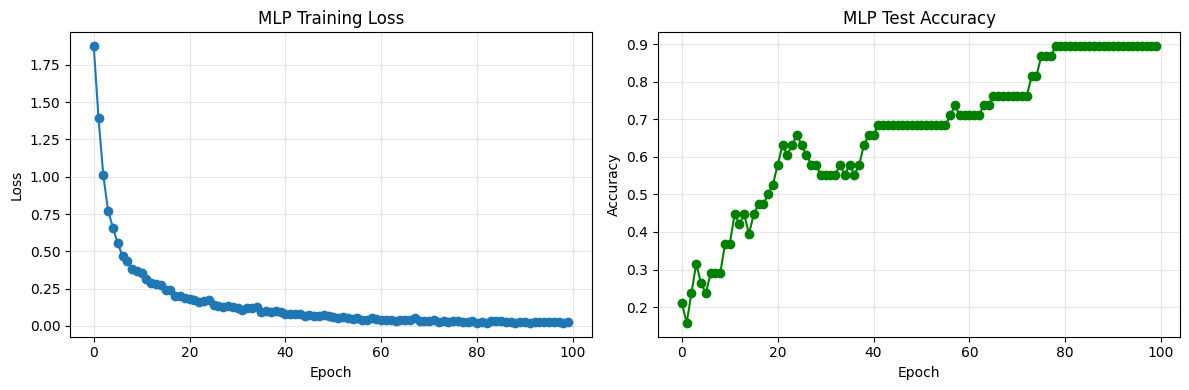


最佳测试准确率: 0.8947


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# =========================================================
# 配置参数
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

cpc_model_path = "./cpc_checkpoints/best_cpc_model.pth"

batch_size_extract = 64
mlp_hidden_dims = [256, 128]
mlp_dropout = 0.3
mlp_epochs = 100
mlp_batch_size = 128
mlp_lr = 1e-3
mlp_weight_decay = 1e-5

# =========================================================
# 1. 标签检查与类别数确定（使用映射后的标签）
# =========================================================
# 确保使用映射后的标签，且是 PyTorch Tensor
y_train = torch.as_tensor(y_train_mapped, dtype=torch.long)
y_test  = torch.as_tensor(y_test_mapped, dtype=torch.long)

# 计算类别数
num_classes = len(torch.unique(y_train))
print(f"训练集标签唯一值: {torch.unique(y_train)}")
print(f"类别数: {num_classes}")

# 验证标签范围是否合法
assert y_train.min() >= 0, "标签包含负数！"
assert y_train.max() < num_classes, "标签最大值超出类别数范围！"

# =========================================================
# 2. 定义 MLP 分类器
# =========================================================
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.3, use_batch_norm=True):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], num_classes))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

# =========================================================
# 3. 加载 CPC 模型并提取特征
# =========================================================
# 请确保 CPCModel 类已定义在当前环境中
model_cpc = CPCModel(
    input_dim=4,
    encoder_hidden_dim=256,
    z_dim=128,
    ar_hidden_dim=256,
    context_dim=128,
    pred_steps=5
).to(device)

checkpoint = torch.load(cpc_model_path, map_location=device)
if 'model_state_dict' in checkpoint:
    model_cpc.load_state_dict(checkpoint['model_state_dict'])
else:
    model_cpc.load_state_dict(checkpoint)
model_cpc.eval()
print("CPC 模型加载成功。")

@torch.no_grad()
def extract_cpc_features(model, X_data, batch_size):
    features_list = []
    total = X_data.shape[0]
    for i in range(0, total, batch_size):
        batch_x = X_data[i:i+batch_size].to(device)
        context = model.get_representations(batch_x)      # (B, seq_len, context_dim)
        pooled = context.mean(dim=1).cpu()                # (B, context_dim)
        features_list.append(pooled)
    return torch.cat(features_list, dim=0)

print("正在提取训练集 CPC 特征...")
X_train_feat = extract_cpc_features(model_cpc, X_train_cpc, batch_size_extract)
print("正在提取测试集 CPC 特征...")
X_test_feat = extract_cpc_features(model_cpc, X_test_cpc, batch_size_extract)

print(f"训练特征形状: {X_train_feat.shape}")
print(f"测试特征形状: {X_test_feat.shape}")

# =========================================================
# 4. 构建 DataLoader（使用映射后标签）
# =========================================================
train_dataset = TensorDataset(X_train_feat, y_train)
test_dataset  = TensorDataset(X_test_feat, y_test)

train_loader = DataLoader(train_dataset, batch_size=mlp_batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=mlp_batch_size, shuffle=False)

# =========================================================
# 5. 初始化 MLP 并训练
# =========================================================
mlp = MLPClassifier(
    input_dim=X_train_feat.shape[1],
    hidden_dims=mlp_hidden_dims,
    num_classes=num_classes,
    dropout=mlp_dropout,
    use_batch_norm=True
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=mlp_lr, weight_decay=mlp_weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"\nMLP 结构:\n{mlp}")

train_losses = []
test_accs = []
best_acc = 0.0

print("\n开始训练 MLP 分类器...")
for epoch in range(1, mlp_epochs + 1):
    mlp.train()
    total_loss = 0.0
    train_batches = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{mlp_epochs}")
    for batch_x, batch_y in pbar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        logits = mlp(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        train_batches += 1
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = total_loss / train_batches
    train_losses.append(avg_train_loss)
    
    # 测试评估
    mlp.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            logits = mlp(batch_x)
            preds = logits.argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    test_acc = correct / total
    test_accs.append(test_acc)
    
    scheduler.step(avg_train_loss)
    print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | Test Acc: {test_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(mlp.state_dict(), "./cpc_checkpoints/best_mlp_classifier.pth")

# =========================================================
# 6. 绘制训练曲线
# =========================================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP Training Loss')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(test_accs, marker='o', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Test Accuracy')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n最佳测试准确率: {best_acc:.4f}")